# Quality control, step by step (QIQ March)
# 质量控制逐步演示（QIQ 3 月）

This notebook loads **March 2024** QIQ LR0100 data (`qiq0324.dat.gz`) and does two things:

1. **Part A — raw tests** — call functions in `ppl.py`, `erl.py`, `closure.py`, `diff_ratio.py`, `k_index.py`, and `tracker.py` directly. Each `*_test` returns **True = pass**. We print **failure row counts per subtest**; **the same row can fail several subtests**, so **sums across subtests are not unique rows**.
2. **Part B — wrapper** — run :func:`~bsrn.qc.wrapper.run_qc` on a **fresh copy** of the data to attach official `flag*` columns, then count **rows with any failure per tier** (unique rows within each tier).

本笔记本加载 QIQ **2024 年 3 月** LR0100 数据，分两部分：**A** 直接调用各模块 `*_test` 并统计每子测试失败行数（同一行可重复计入）；**B** 对干净副本调用 **`run_qc`** 生成 `flag*` 列并按层统计「至少一项失败」的行数。


## 1. Imports and path / 导入与路径

In [1]:
import os
import re

import numpy as np
import pandas as pd

import bsrn
from bsrn.constants import BSRN_STATIONS
from bsrn.physics import geometry
from bsrn.qc import closure, diff_ratio, erl, k_index, ppl, tracker
from bsrn.qc.wrapper import run_qc

# BSRN name pattern {ccc}{MM}{YY}.dat.gz (e.g. qiq0324 = QIQ Mar 2024); cwd = repo root
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0324.dat.gz"

_basename = os.path.basename(INPUT_FILE)
_m = re.match(r"^([A-Za-z]{3})", _basename)
if not _m:
    raise ValueError(f"Cannot parse BSRN station code from filename: {_basename}")
STATION_CODE = _m.group(1).upper()

pd.options.display.max_columns = None

## 2. Load data / 加载数据

In [2]:
df = bsrn.io.reader.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
if df is None:
    raise FileNotFoundError(f"Could not read {INPUT_FILE}. Download data for {STATION_CODE} first.")

print(f"Station: {STATION_CODE}  |  Rows: {len(df):,}  |  {df.index.min()} … {df.index.max()} UTC")
print("Columns:", ", ".join(df.columns))

Station: QIQ  |  Rows: 44,640  |  2024-03-01 00:00:00+00:00 … 2024-03-31 23:59:00+00:00 UTC
Columns: ghi, bni, dhi, lwd, temp, rh, pressure


## 3. Solar geometry (shared by all tests) / 太阳几何（各测试共用）

In [3]:
if STATION_CODE not in BSRN_STATIONS:
    raise KeyError(f"Unknown station {STATION_CODE} in BSRN_STATIONS")
meta = BSRN_STATIONS[STATION_CODE]
lat, lon, elev = meta["lat"], meta["lon"], meta["elev"]

solpos = geometry.get_solar_position(df.index, lat, lon, elev)
zenith = solpos["zenith"]
bni_extra = geometry.get_bni_extra(df.index)
ghi_extra = geometry.get_ghi_extra(df.index, zenith)

## 4. Part A — Individual `*_test` functions / A 部分 — 各 `*_test` 函数

Helpers: **`n_fail`** = rows where the test **fails** (i.e. pass is False). **`n_fail_any`** = rows where **at least one** of the given pass Series is False (unique rows within that list).

辅助函数：**`n_fail`** 为失败行数；**`n_fail_any`** 为「至少一项未通过」的行数（同一行只计一次）。


In [4]:
def n_fail(pass_bool):
    """Number of rows failing: *_test returns True=pass."""
    p = pass_bool if isinstance(pass_bool, pd.Series) else pd.Series(pass_bool, index=df.index)
    return int((~p.fillna(False)).sum())


def n_fail_any(*pass_series):
    """Rows where at least one test fails (unique rows; not sum of per-test counts)."""
    stacks = []
    for s in pass_series:
        p = s if isinstance(s, pd.Series) else pd.Series(s, index=df.index)
        stacks.append(p.fillna(False).to_numpy())
    all_pass = np.logical_and.reduce(stacks)
    return int((~all_pass).sum())

### 4.1 PPL (`ppl.py`)

In [5]:
pass_ghi = ppl.ghi_ppl_test(df["ghi"], zenith, bni_extra)
pass_bni = ppl.bni_ppl_test(df["bni"], bni_extra)
pass_dhi = ppl.dhi_ppl_test(df["dhi"], zenith, bni_extra)
print("PPL GHI fail rows:", n_fail(pass_ghi))
print("PPL BNI fail rows:", n_fail(pass_bni))
print("PPL DHI fail rows:", n_fail(pass_dhi))
if "lwd" in df.columns:
    pass_lwd = ppl.lwd_ppl_test(df["lwd"])
    print("PPL LWD fail rows:", n_fail(pass_lwd))
else:
    pass_lwd = None
    print("PPL LWD: (no lwd column)")
_ppl = [pass_ghi, pass_bni, pass_dhi] + ([pass_lwd] if pass_lwd is not None else [])
print("PPL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_ppl))
print("(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)")

PPL GHI fail rows: 7947
PPL BNI fail rows: 6
PPL DHI fail rows: 9685
PPL LWD fail rows: 8
PPL tier — rows failing ≥1 subtest (unique): 10592
(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)


### 4.2 ERL (`erl.py`)

In [6]:
e_ghi = erl.ghi_erl_test(df["ghi"], zenith, bni_extra)
e_bni = erl.bni_erl_test(df["bni"], zenith, bni_extra)
e_dhi = erl.dhi_erl_test(df["dhi"], zenith, bni_extra)
print("ERL GHI fail rows:", n_fail(e_ghi))
print("ERL BNI fail rows:", n_fail(e_bni))
print("ERL DHI fail rows:", n_fail(e_dhi))
if "lwd" in df.columns:
    e_lwd = erl.lwd_erl_test(df["lwd"])
    print("ERL LWD fail rows:", n_fail(e_lwd))
else:
    e_lwd = None
_erl = [e_ghi, e_bni, e_dhi] + ([e_lwd] if e_lwd is not None else [])
print("ERL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_erl))

ERL GHI fail rows: 18318
ERL BNI fail rows: 13
ERL DHI fail rows: 19271
ERL LWD fail rows: 8
ERL tier — rows failing ≥1 subtest (unique): 19353


### 4.3 Closure (`closure.py`)

In [7]:
c_low = closure.closure_low_sza_test(df["ghi"], df["bni"], df["dhi"], zenith)
c_high = closure.closure_high_sza_test(df["ghi"], df["bni"], df["dhi"], zenith)
print("Closure low-SZA  fail rows:", n_fail(c_low))
print("Closure high-SZA fail rows:", n_fail(c_high))
print("Closure tier — rows failing ≥1 subtest (unique):", n_fail_any(c_low, c_high))

Closure low-SZA  fail rows: 11
Closure high-SZA fail rows: 18
Closure tier — rows failing ≥1 subtest (unique): 29


### 4.4 Diffuse ratio (`diff_ratio.py`)

In [8]:
d_kkt = diff_ratio.k_kt_combined_test(df["ghi"], df["dhi"], bni_extra, zenith)
d_klo = diff_ratio.k_low_sza_test(df["ghi"], df["dhi"], zenith)
d_khi = diff_ratio.k_high_sza_test(df["ghi"], df["dhi"], zenith)
print("K–Kt combined fail rows:", n_fail(d_kkt))
print("k low-SZA       fail rows:", n_fail(d_klo))
print("k high-SZA      fail rows:", n_fail(d_khi))
print("Diffuse-ratio tier — rows failing ≥1 subtest (unique):", n_fail_any(d_kkt, d_klo, d_khi))

K–Kt combined fail rows: 20
k low-SZA       fail rows: 1
k high-SZA      fail rows: 0
Diffuse-ratio tier — rows failing ≥1 subtest (unique): 20


### 4.5 K-indices (`k_index.py`)

In [9]:
k_kbkt = k_index.kb_kt_test(df["ghi"], df["bni"], bni_extra, zenith)
k_kb = k_index.kb_limit_test(df["bni"], bni_extra, elev, df["ghi"])
k_kt = k_index.kt_limit_test(df["ghi"], bni_extra, zenith)
print("Kb vs Kt fail rows:", n_fail(k_kbkt))
print("Kb limit   fail rows:", n_fail(k_kb))
print("Kt limit   fail rows:", n_fail(k_kt))
print("K-index tier — rows failing ≥1 subtest (unique):", n_fail_any(k_kbkt, k_kb, k_kt))

Kb vs Kt fail rows: 0
Kb limit   fail rows: 0
Kt limit   fail rows: 0
K-index tier — rows failing ≥1 subtest (unique): 0


### 4.6 Tracker (`tracker.py`)

In [10]:
pass_trk = tracker.tracker_off_test(
    df["ghi"], df["bni"], zenith, ghi_extra=ghi_extra, ghi_clear=None, bni_clear=None
)
print("Tracker-off fail rows:", n_fail(pass_trk))

Tracker-off fail rows: 30


## 5. Part B — `run_qc` and tier row counts / B 部分 — `run_qc` 与各层行数

Run the library wrapper on a **clean copy** of the data, then count rows with **≥1 failure** in each tier from the **`flag*`** columns (**1 = fail**). Within a tier, a row is counted **once** if any flag in that tier is 1.

对干净副本运行 **`run_qc`**，再按各层 **`flag*`** 统计「至少一项未通过」的行数（**1 = 未通过**）。同一层内任一子项为 1 则该行在该层计一次。

The mapping of flags to tiers is stored in **`TIER_COLS`** for reuse in §7.

层与 `flag*` 的对应关系保存在 **`TIER_COLS`** 中，供 §7 复用。


In [11]:
df_qc = run_qc(df.copy(), station_code=STATION_CODE)

TIER_COLS = {
    "PPL": [c for c in df_qc.columns if c.startswith("flagPPL")],
    "ERL": [c for c in df_qc.columns if c.startswith("flagERL")],
    "Closure": [c for c in df_qc.columns if c.startswith("flag3")],
    "Diffuse k / K–Kt": ["flagKKt", "flagKlowSZA", "flagKhighSZA"],
    "K-indices": ["flagKbKt", "flagKb", "flagKt"],
    "Tracker": ["flagTracker"],
}

rows = len(df_qc)
print(f"Total rows: {rows:,}")
print("--- Part B: rows with ≥1 fail per tier (flag* columns) ---")
for name, want in TIER_COLS.items():
    cols = [c for c in want if c in df_qc.columns]
    if not cols:
        continue
    n = int(df_qc[cols].eq(1).any(axis=1).sum())
    print(f"{name}: rows with ≥1 fail in tier = {n:,}  (flags: {', '.join(cols)})")

Total rows: 44,640
--- Part B: rows with ≥1 fail per tier (flag* columns) ---
PPL: rows with ≥1 fail in tier = 10,592  (flags: flagPPLGHI, flagPPLBNI, flagPPLDHI, flagPPLLWD)
ERL: rows with ≥1 fail in tier = 19,353  (flags: flagERLGHI, flagERLBNI, flagERLDHI, flagERLLWD)
Closure: rows with ≥1 fail in tier = 29  (flags: flag3lowSZA, flag3highSZA)
Diffuse k / K–Kt: rows with ≥1 fail in tier = 20  (flags: flagKKt, flagKlowSZA, flagKhighSZA)
K-indices: rows with ≥1 fail in tier = 0  (flags: flagKbKt, flagKb, flagKt)
Tracker: rows with ≥1 fail in tier = 30  (flags: flagTracker)


## 6. Compare Part A vs Part B (per tier) / 对比 A 与 B（按层）

**Part A** uses raw `*_test` pass/fail booleans and **`n_fail_any`** (tier unique fail rows from §4). **Part B** uses **`run_qc`** `flag*` columns with the same tier groupings. Counts should **match** for each tier.

**A 部分** 为 §4 中原始 `*_test` 与 **`n_fail_any`** 的按层失败行数；**B 部分** 为 **`run_qc`** 的 `flag*`。各层计数应**一致**。

Optional: per-flag sums (wrapper) in the next cell.

可选：下一单元为各 `flag*` 失败次数（非按层唯一行）。


In [12]:
part_a_tier = {
    "PPL": n_fail_any(*_ppl),
    "ERL": n_fail_any(*_erl),
    "Closure": n_fail_any(c_low, c_high),
    "Diffuse k / K–Kt": n_fail_any(d_kkt, d_klo, d_khi),
    "K-indices": n_fail_any(k_kbkt, k_kb, k_kt),
    "Tracker": n_fail(pass_trk),
}

part_b_tier = {}
for name, want in TIER_COLS.items():
    cols = [c for c in want if c in df_qc.columns]
    if cols:
        part_b_tier[name] = int(df_qc[cols].eq(1).any(axis=1).sum())

cmp = pd.DataFrame(
    {
        "Part A (§4 raw *_test, tier unique fails)": pd.Series(part_a_tier),
        "Part B (§5 run_qc flag*, any fail in tier)": pd.Series(part_b_tier),
    }
)
cmp["match"] = cmp.iloc[:, 0] == cmp.iloc[:, 1]
cmp

,"Part A (§4 raw *_test, tier unique fails)","Part B (§5 run_qc flag*, any fail in tier)",match
PPL,10592,10592,True
ERL,19353,19353,True
Closure,29,29,True
Diffuse k / K–Kt,20,20,True
K-indices,0,0,True
Tracker,30,30,True


In [13]:
flag_cols = [c for c in df_qc.columns if c.startswith("flag")]
df_qc[flag_cols].sum().sort_index()

flag3highSZA       18
flag3lowSZA        11
flagERLBNI         13
flagERLDHI      19271
flagERLGHI      18318
flagERLLWD          8
flagKKt            20
flagKb              0
flagKbKt            0
flagKhighSZA        0
flagKlowSZA         1
flagKt              0
flagPPLBNI          6
flagPPLDHI       9685
flagPPLGHI       7947
flagPPLLWD          8
flagTracker        30
dtype: int64

## 8. Daily QC audit table / 日尺度 QC 审计表

**`get_daily_stats`** (in `bsrn.utils.quality`) aggregates the loaded month to **one row per calendar day**: sunshine-duration metrics (**SD**), per-component **PPL / ERL** failure **minute counts**, and composite flags (**closure**, **diffuse ratio**, **K-index**, **tracker**). **`plot_qc_table`** draws these values as a **heatmap-style table** (Wong palette: passes white, stats sky blue, tier failures by level).

**`get_daily_stats`**（`bsrn.utils.quality`）将本月数据按**日**汇总：日照相关 **SD**、各分量 **PPL/ERL** 失败**分钟数**、以及 **closure / diffuse ratio / K-index / tracker** 合成项。**`plot_qc_table`** 以**类表格热图**展示（Wong 色：通过为白，统计量为天蓝，各层失败按等级着色）。

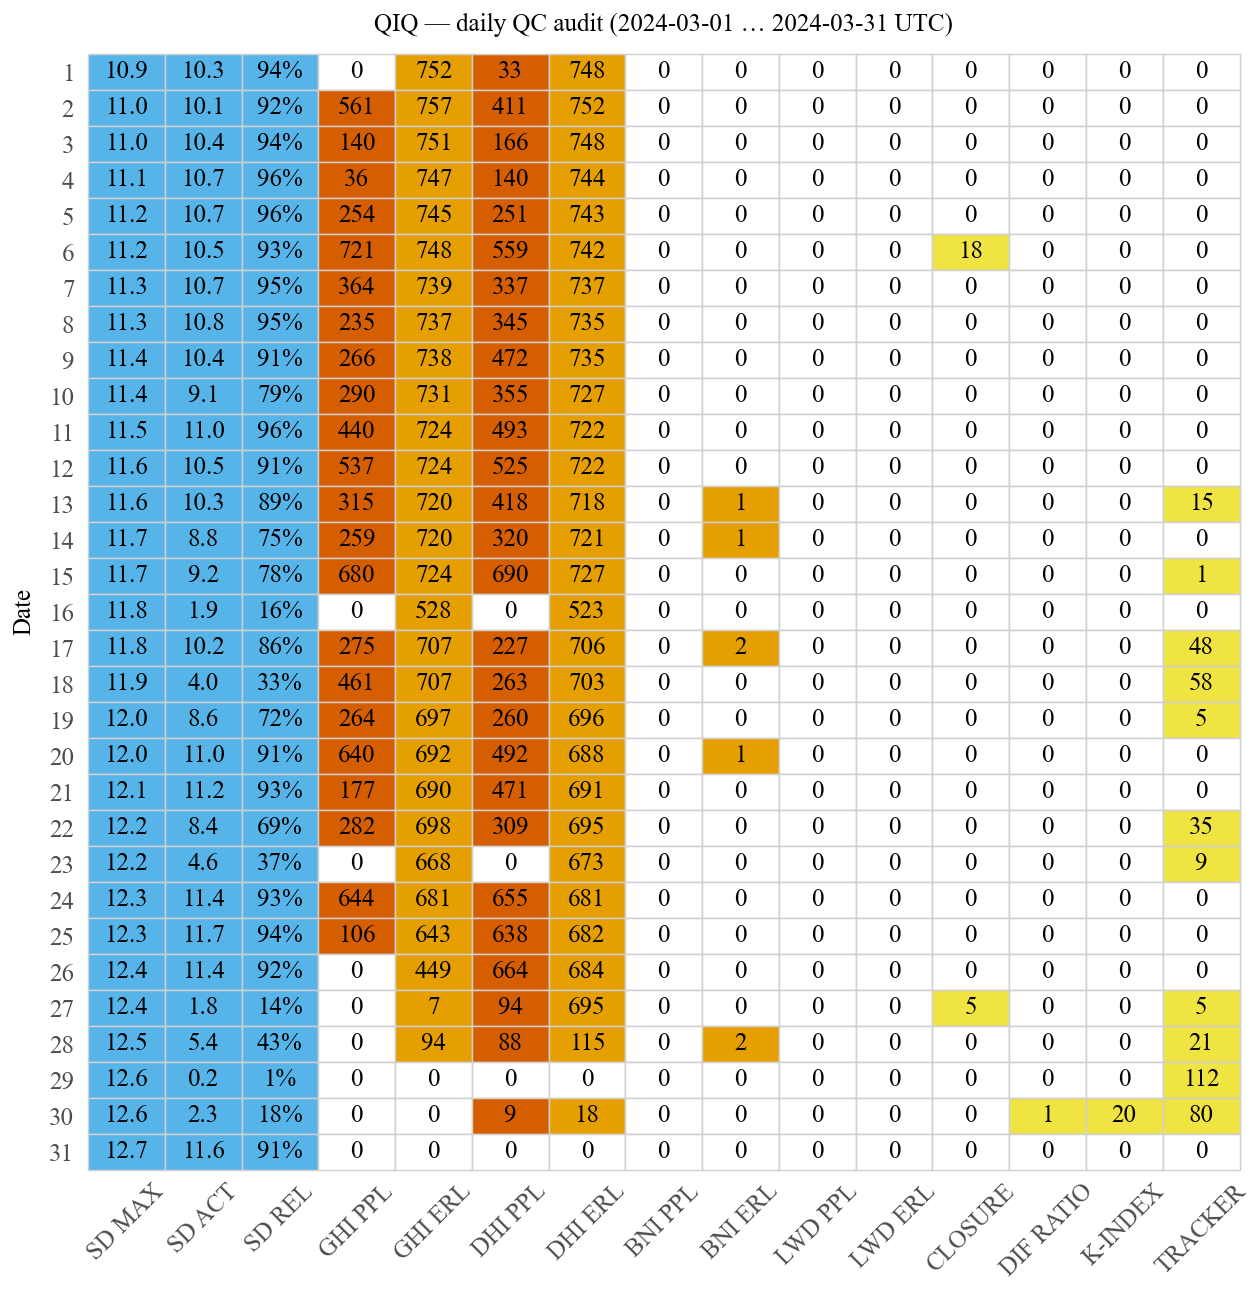

In [14]:
from bsrn.utils.quality import get_daily_stats
from bsrn.visualization.qc_table import plot_qc_table

daily_stats = get_daily_stats(df.copy(), lat, lon, elev, station_code=STATION_CODE)
qc_table_title = (
    f"{STATION_CODE} — daily QC audit ({df.index.min().date()} … {df.index.max().date()} UTC)"
)
plot_qc_table(daily_stats, title=qc_table_title)

## 9. Faceted timeseries for 27 March (UTC) / 3 月 27 日分面时间序列

**`plot_bsrn_timeseries_day`** (in `bsrn.visualization.timeseries`) reads the **same monthly** `INPUT_FILE` as §2 and draws the standard **3×3** layout (GHI/BNI/DHI/LWD, diagnostics, met) for **one UTC calendar day**. With **`station_code`**, clear-sky curves and **Level 1–6 QC failure markers** (Wong colours) are shown on the relevant panels.

**`plot_bsrn_timeseries_day`**（`bsrn.visualization.timeseries`）使用 §2 的**同一月** `INPUT_FILE`，绘制 **UTC** **某日**的 **3×3** 分面（辐照、诊断、气象）。提供 **`station_code`** 时叠加晴空线与 **1–6 级 QC 失败标记**（Wong 色）。

March **27** is the day highlighted elsewhere for **tracker** issues; adjust **`DAY_UTC`** to explore other days.

3 月 **27** 日为与跟踪器问题相关的示例日；可改 **`DAY_UTC`** 查看其他日。

/Volumes/Macintosh Research/Data/bsrn-qc/src/bsrn/visualization/timeseries.py:160: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


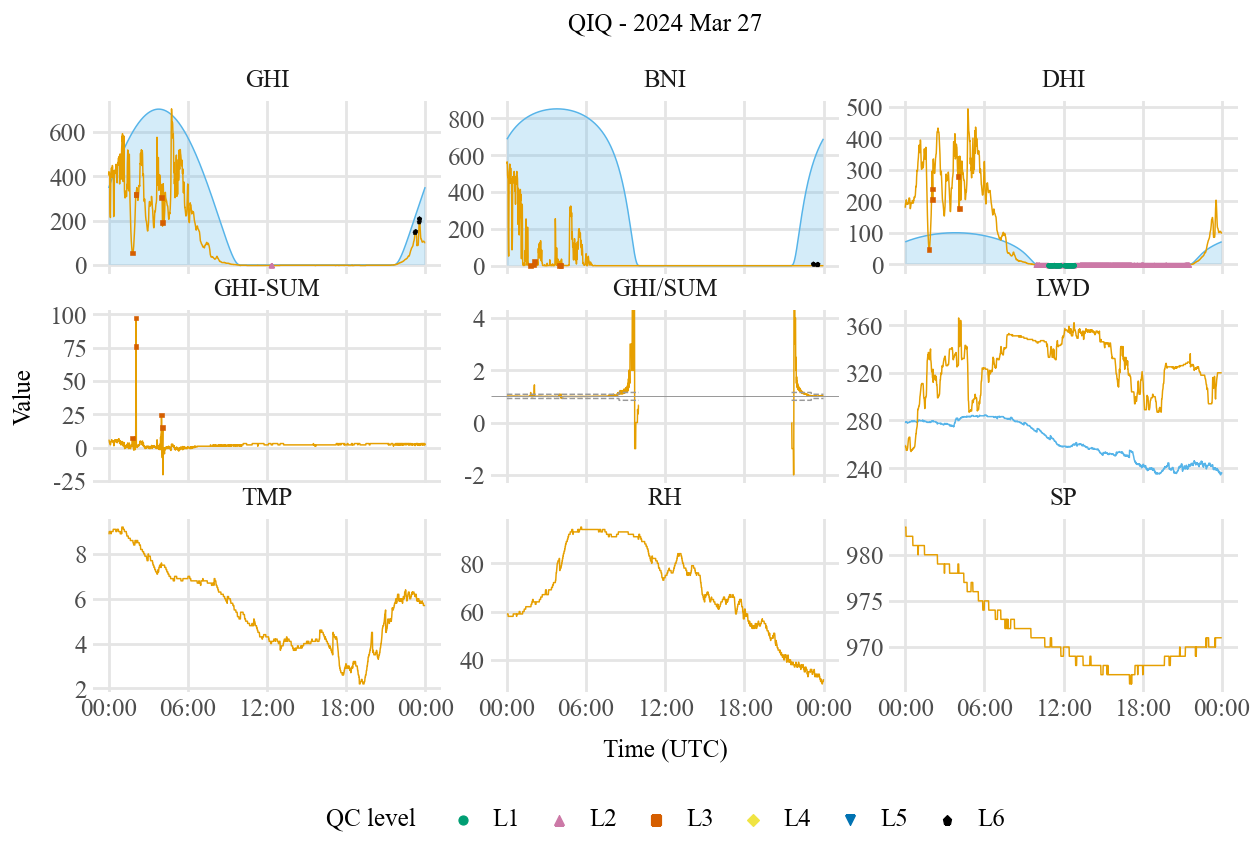

In [15]:
from bsrn.visualization.timeseries import plot_bsrn_timeseries_day

DAY_UTC = "2024-03-27"
plot_bsrn_timeseries_day(
    INPUT_FILE,
    DAY_UTC,
    station_code=STATION_CODE,
    apply_qc=False,
    show_qc_markers=True,
)